### Time evolution + Trotter operator generator

#### Heisenberg Chain Hamiltonian

The Heisenberg chain is a fundamental model in condensed matter physics used to describe interacting quantum spins. The Hamiltonian for an anisotropic XXZ Heisenberg chain with an external magnetic field is given by:

$H = J\sum_{i=1}^{L-1} (S_i^x S_{i+1}^x + S_i^y S_{i+1}^y + \Delta S_i^z S_{i+1}^z) + h\sum_{i=1}^L S_i^z$

Where:
- $L$ is the number of qubits (spin-1/2 particles).
- $S_i^x, S_i^y, S_i^z$ are the Pauli spin operators for the $i$-th qubit.
- $J$ is the coupling strengths between neighboring spins.
- $\Delta$ is the anisotropy parameter
- $h$ is the strength of the external magnetic field acting on each spin.


In [ ]:
import numpy as np
from scipy.sparse import csr_matrix, identity, kron
from scipy.sparse.linalg import expm, norm
from scipy.constants import pi
# from scipy.sparse.linalg import norm

# Define Pauli matrices (as sparse matrices for efficiency)
sigma_x = csr_matrix(np.array([[0, 1], [1, 0]], dtype=complex))
sigma_y = csr_matrix(np.array([[0, -1j], [1j, 0]], dtype=complex))
sigma_z = csr_matrix(np.array([[1, 0], [0, -1]], dtype=complex))
identity_2x2 = csr_matrix(np.array([[1, 0], [0, 1]], dtype=complex))

In [ ]:
# Global model parameters
n = 1        # Number of qubits (L)
J = 1.0      # Isotropic exchange coupling strength
h = 0.5         # Strength of the external magnetic field in the z-direction

t = 2.0 # Target simulation time

In [ ]:
# Helper function to create an operator acting on specific qubit(s)
def get_local_operator(op, num_qubits, *qubit_indices):
    """
    Generates a global operator (tensor product) acting on specific qubits.

    Args:
        op (csr_matrix): The local operator (e.g., Pauli matrix) to apply.
        num_qubits (int): Total number of qubits in the system.
        identity_op (csr_matrix): The 2x2 identity matrix.
        qubit_indices (tuple): Indices of the qubits where `op` acts.

    Returns:
        csr_matrix: The global operator as a sparse matrix.
    """
    operators = [identity_2x2] * num_qubits
    for idx in qubit_indices:
        if not (0 <= idx < num_qubits):
            raise IndexError(f"Qubit index {idx} out of bounds for {num_qubits} qubits.")
        operators[idx] = op

    # Perform Kronecker product iteratively
    current_op = operators[0]
    for i in range(1, num_qubits):
        current_op = kron(current_op, operators[i])
    return current_op

In [ ]:
def get_individual_hamiltonian_terms(
    num_qubits: int,
    J: float,
    h: float
) -> list[csr_matrix]:
    """
    Decomposes the isotropic Heisenberg chain Hamiltonian into a list of individual
    Pauli string terms.

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength for x, y, and z terms.
        h (float): Strength of the external magnetic field in the z-direction.

    Returns:
        list[csr_matrix]: A list of sparse matrices, each representing one term
                          in the Hamiltonian.
    """
    if num_qubits < 1:
        raise ValueError("Number of qubits must be at least 1.")

    terms = []

    # Interaction terms (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z)
    # Open boundary conditions: sum from i=0 to num_qubits-2 (L-1 interactions)
    for i in range(num_qubits - 1):
        terms.append((J) * get_local_operator(sigma_x, num_qubits, i, i + 1))
        terms.append((J) * get_local_operator(sigma_y, num_qubits, i, i + 1))
        terms.append((0.9*J) * get_local_operator(sigma_z, num_qubits, i, i + 1)) #played with some anisotropy here

    # Magnetic field terms (h S_i^z)
    # Sum from i=0 to num_qubits-1 (L terms)
    for i in range(num_qubits):
        terms.append((h) * get_local_operator(sigma_z, num_qubits, i))
        terms.append((h) * get_local_operator(sigma_x, num_qubits, i))

    return terms

### Generate Trotterized operator

In [ ]:
def generate_trotter_second_order(
    num_qubits: int,
    J: float,
    h: float,
    t: float,
    trotter_dt: float
) -> csr_matrix:
    """
    Generates the second-order Trotterized time evolution operator for the
    isotropic Heisenberg chain with a z-direction external magnetic field,
    by decomposing the Hamiltonian into individual Pauli string terms.

    The Trotter formula used is U(dt) = Product_{k=1..M} exp(-i H_k dt/2) * Product_{k=M..1} exp(-i H_k dt/2).

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength.
        h (float): Strength of the external magnetic field in the z-direction.
        trotter_dt (float): The Trotter time step.

    Returns:
        csr_matrix: The second-order Trotterized time evolution operator.
    """
    # Ensure number of Trotter steps is integer
    # The trotter_dt is derived from t/step, so t/trotter_dt should always be an integer.
    # However, floating point inaccuracies can cause is_integer() to return False.
    # We cast it to int here to handle that.
    num_trotter_steps = int(round(t / trotter_dt))

    # Get all individual Pauli string terms from the Hamiltonian
    list_of_terms = get_individual_hamiltonian_terms(num_qubits, J, h)

    dim = 2**num_qubits
    U_forward = identity(dim, dtype=complex, format='csr')
    U_backward = identity(dim, dtype=complex, format='csr')

    # First half of the Trotter expansion (forward product)
    for term in list_of_terms:
        U_forward = U_forward @ expm(-0.5j * term * trotter_dt)

    # Second half of the Trotter expansion (reverse product)
    for term in reversed(list_of_terms):
        U_backward = U_backward @ expm(-0.5j * term * trotter_dt)

    # Combine for the full second-order Trotter step and return full Trotter operator
    U_single_step = U_forward @ U_backward
    U_trotter = U_single_step**(num_trotter_steps)
    return U_trotter

In [ ]:
# Layer of x rotations to simulate bitflip noise
def add_x_rotations(
    n_qubit_unitary: csr_matrix,
    num_qubits: int,
    mean: float = 0.0,
    std_dev: float = pi / 2
) -> csr_matrix:
    """
    Applies an n-fold tensor product of X-rotations to an n-qubit unitary.
    Each X-rotation angle is drawn from a Gaussian distribution.

    Args:
        n_qubit_unitary (csr_matrix): The input n-qubit unitary.
        num_qubits (int): The number of qubits in the system.
        mean (float): Mean of the Gaussian distribution for rotation angles.
        std_dev (float): Standard deviation of the Gaussian distribution for rotation angles.

    Returns:
        csr_matrix: The resulting unitary after applying the X-rotations.
    """
    if n_qubit_unitary.shape != (2**num_qubits, 2**num_qubits):
        raise ValueError("Input unitary shape does not match the number of qubits.")

    # 1. Generate num_qubits angles from a Gaussian distribution
    rotation_angles = np.random.normal(mean, std_dev, num_qubits)

    # 2. Construct the num_qubits-fold tensor product of X-rotation unitaries
    composed_x_rotation_unitary = None
    for i in range(num_qubits):
        angle = rotation_angles[i]
        # X-rotation matrix for a single qubit: U_x(theta) = exp(-i * theta/2 * sigma_x)
        single_qubit_x_rotation = expm(-1j * (angle / 2) * sigma_x)

        if composed_x_rotation_unitary is None:
            composed_x_rotation_unitary = single_qubit_x_rotation
        else:
            composed_x_rotation_unitary = kron(composed_x_rotation_unitary, single_qubit_x_rotation)

    # 3. Apply to the input unitary (assuming new rotations are applied after the existing unitary)
    resultant_unitary = composed_x_rotation_unitary @ n_qubit_unitary
    return resultant_unitary

In [ ]:
def generate_trotter_operators_for_dt_range(
    num_qubits: int,
    J: float,
    h: float,
    t: float,
    trotter_dt_range: list[float]
) -> list[csr_matrix]:
    """
    Generates a *list* of second-order Trotterized time evolution operators
    for a given range of trotter_dt values.

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength.
        h (float): Strength of the external magnetic field in the z-direction.
        t (float): Total simulation time.
        trotter_dt_range (list[float]): A list of Trotter time steps to evaluate.

    Returns:
        list[csr_matrix]: A list of csr_matrix objects, each representing
                          a second-order Trotterized time evolution operator
                          for a specific trotter_dt from the input range.
    """
    trotter_operators = []
    for trotter_dt in trotter_dt_range:
        # Ensure t is an integer multiple of trotter_dt for each calculation
        # if not (t / trotter_dt).is_integer():
        #    print(f"Warning: Total time {t} is not an integer multiple of trotter_dt = {trotter_dt}. Skipping this dt.")
        #    continue

        operator = generate_trotter_second_order(
            num_qubits, J, h, t, trotter_dt
        )
        trotter_operators.append(operator)
    return trotter_operators

In [ ]:
def generate_err_trotter_operators_for_dt_range(
    num_qubits: int,
    trotter_operators: list[csr_matrix],
    std_dev: float = pi / 2
) -> list[csr_matrix]:
    """
    Applies X-rotations (simulated measurement noise) to a *list* of
    second-order Trotterized time evolution operators.

    Args:
        num_qubits (int): The number of qubits (L).
        trotter_operators (list[csr_matrix]): A list of pre-computed Trotter operators.
        std_dev (float): Standard deviation of the Gaussian distribution for rotation angles.

    Returns:
        list[csr_matrix]: A list of csr_matrix objects, each representing
                          a Trotterized time evolution operator with added noise.
    """
    err_trotter_operators = []
    for operator in trotter_operators:
        # Ensure t is an integer multiple of trotter_dt for each calculation
        # if not (t / trotter_dt).is_integer():
        #    print(f"Warning: Total time {t} is not an integer multiple of trotter_dt = {trotter_dt}. Skipping this dt.")
        #    continue

        err_operator = add_x_rotations(
            operator,
            num_qubits,
            0.0,
            std_dev
        )
        err_trotter_operators.append(err_operator)
    return err_trotter_operators

#### Generate exact time evolution operator

In [ ]:
def generate_heisenberg_hamiltonian(
    num_qubits: int,
    J: float,
    h: float
) -> csr_matrix:
    """
    Generates the Hamiltonian matrix for an isotropic Heisenberg chain
    with a z-direction external magnetic field (open boundary conditions).

    The Hamiltonian is given by:
    $H = \sum_{i=1}^{L-1} (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z) + \sum_{i=1}^L (h S_i^z)$

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength for x, y, and z terms.
        h (float): Strength of the external magnetic field in the z-direction.

    Returns:
        csr_matrix: The Hamiltonian matrix in sparse format.
    """

    if num_qubits < 1:
        raise ValueError("Number of qubits must be at least 1.")

    dim = 2**num_qubits
    H = csr_matrix((dim, dim), dtype=complex)
    I = identity_2x2

    def get_local_operator(op, *qubit_indices):
        operators = [I] * num_qubits
        for idx in qubit_indices:
            if not (0 <= idx < num_qubits):
                raise IndexError(f"Qubit index {idx} out of bounds for {num_qubits} qubits.")
            operators[idx] = op
        current_op = operators[0]
        for i in range(1, num_qubits):
            current_op = kron(current_op, operators[i])
        return current_op

    # Interaction terms (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z)
    # Open boundary conditions: sum from i=0 to num_qubits-2 (L-1 interactions)
    for i in range(num_qubits - 1):
        H += (J) * get_local_operator(sigma_x, i, i + 1)
        H += (J) * get_local_operator(sigma_y, i, i + 1)
        H += (0.9*J) * get_local_operator(sigma_z, i, i + 1)

    # Magnetic field terms (h S_i^z)
    # Sum from i=0 to num_qubits-1 (L terms)
    for i in range(num_qubits):
        H += (h) * get_local_operator(sigma_z, i)
        H += (h) * get_local_operator(sigma_x, i)

    return H

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3706/325158966.py:11: SyntaxWarning: invalid escape sequence '\s'
  $H = \sum_{i=1}^{L-1} (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z) + \sum_{i=1}^L (h S_i^z)$


### Error evaluator

Here we evaluate error between an input matrix with an exact time evolution operator. We will test error via operator norm.

We now calculate the error between the `exact` time evolution operator and the `trotter_operator`.

In [ ]:
def op_norm_error(
    matrix_1: csr_matrix,
    matrix_2: csr_matrix
) -> float:
    """
    Computes the operator of the difference between two matrices (given in sparse format).
    Note error tolerance is around 9e-7

    Args:
        matrix_1 (csr_matrix): The first sparse matrix.
        matrix_2 (csr_matrix): The second sparse matrix.

    Returns:
        float: The operator norm of their difference.
    """
    # Ensure matrices have the same shape for subtraction
    if matrix_1.shape != matrix_2.shape:
        raise ValueError("Matrices must have the same shape for comparison.")

    # Calculate the difference between the two matrices
    diff_matrix = matrix_1 - matrix_2

    # Compute the operator norm (2-norm) of the difference
    error = norm(diff_matrix, 2)
    return error

In [ ]:
# test: calculate the error for test Trotter operator
error_value = op_norm_error(exact, trotter_operator)

print(f"Operator norm error is: {error_value}")

Operator norm error is: 0.5425676014220184


### Generate Trotter data and plot

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [ ]:
# Global model parameters
n = 8        # Number of qubits (L). S: choose small value for prototyping. Eventually n=8 is not unreasonable. Maybe n=10 possible at a push.
J = 1.0      # Isotropic exchange coupling strength
h = -1.0         # Strength of the external magnetic field in the z-direction

t = 2.0 # Target simulation time

# Data parameters
trotter_step_counts=list(range(5,61)) # range of Trotter step number (our proxy for gate depth)
trotter_step_sizes=[t/step for step in trotter_step_counts] # Trotter step sizes

In [ ]:
trotter_operators_list = generate_trotter_operators_for_dt_range(
    n, J, h, t, trotter_step_sizes
)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [ ]:
# Generate exact evolution operator
heisenberg_hamiltonian = generate_heisenberg_hamiltonian(n, J, h)
exact_operator = expm(-1j * heisenberg_hamiltonian * t)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


In [ ]:
# List of operator norm errors for above generated Trotter errors
error_list=[]
for m in trotter_operators_list:
    error = op_norm_error(m, exact_operator)
    error_list.append(error)
print(f"Errors are: {error_list}")

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[1.47894233e-05]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
1.478942329775182e-05.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[1.47894233e-05]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[0.00019069]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
0.00019068611579413627.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_s

Errors are: [np.float64(1.751458424219062), np.float64(1.3736603439520882), np.float64(1.0678872127902375), np.float64(0.8421964491442724), np.float64(0.6768599645651794), np.float64(0.5540345410141077), np.float64(0.4610194196709614), np.float64(0.38919546685416195), np.float64(0.3327208901170958), np.float64(0.2875826063848615), np.float64(0.2509734075737403), np.float64(0.22089197569325544), np.float64(0.19588500615896087), np.float64(0.1748788239812448), np.float64(0.1570674681165703), np.float64(0.14183702702733525), np.float64(0.12871359695073206), np.float64(0.11732683821821566), np.float64(0.107384059370992), np.float64(0.09865155311329998), np.float64(0.09094096644155492), np.float64(0.08409910796122876), np.float64(0.07800038038285942), np.float64(0.07254112665806339), np.float64(0.06763499627968765), np.float64(0.06320981548598364), np.float64(0.059204880759896696), np.float64(0.055568531056920445), np.float64(0.052256923834888794), np.float64(0.049232716657801705), np.float

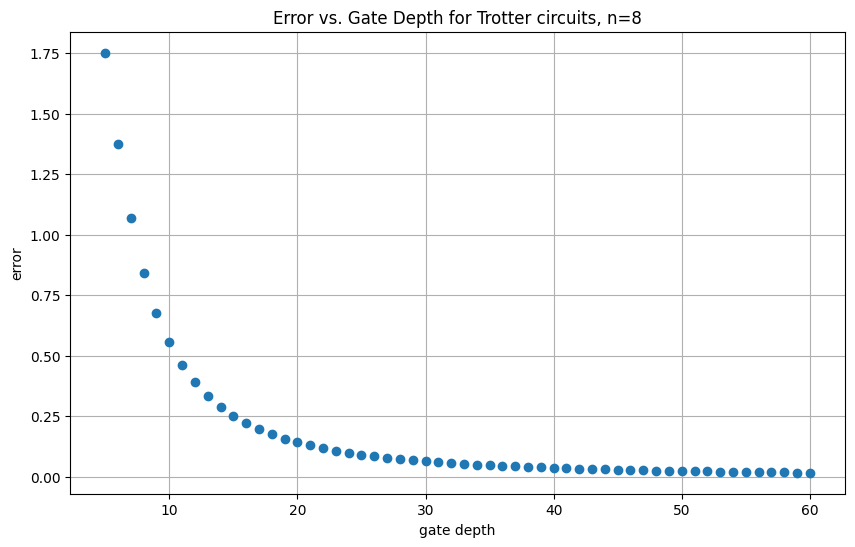

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(trotter_step_counts, error_list, marker='o', linestyle='none')
plt.xlabel('gate depth')
plt.ylabel('error')
plt.title(f'Error vs. Gate Depth for Trotter circuits, n={n}')
plt.grid(True)
plt.show()
#S: maybe we change to log plot, option open for that

### Generate extrapolated data and plot.

We want to take extrapolation schedules from prev. data (well-conditioned and brute force) to generate extrapolated trotter operators. Then look at error. Importantly, the number of Trotter steps should fall within whatever trotter_step_counts is defined to be above. Thus, s should be chosen in a bespoke way so that the max number of Trotter steps (q_max/s) falls within the range of trotter_step_counts. For a given extrapolation scheme, we want to plot all data points that can fit within the range. For instance, if the range is [10,20] and I have an extrapolation scheme of q_max=5, I want to generate extrapolated Trotter operators for 1/s=2,3,4 and this would give me three data points to add to above plot. We also want colors as before for sample overhead, so these 3 data points should have the same color corresponding to their (b_norm)^2

recall trotter step size is s*t (t is target simulation time)

see above trotter_operators_list which already gives you a list of Trotter operators for p=2 for a range of Trotter step sizes

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Schemes contributing points: 12
Total Richardson points plotted: 72


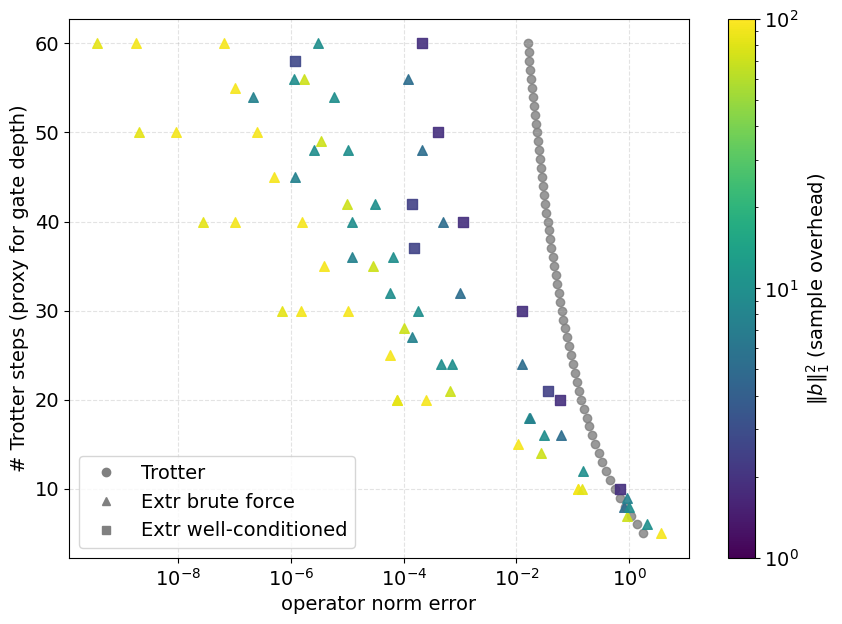

In [ ]:
from matplotlib.colors import LogNorm

# Set global font size for plots
plt.rcParams.update({'font.size': 14})

p_order = 2

# Existing p=2 Trotter operators from earlier cells, keyed by integer step count N.
step_to_trotter = {int(N): op for N, op in zip(trotter_step_counts, trotter_operators_list)}
step_min, step_max = min(trotter_step_counts), max(trotter_step_counts)

# Representative schedules from prior data (wc + opt).
active_schemes = [
    {"mode": "wc",  "label": "wc q=[10,4]",      "q_grid": (10, 4),       "b": np.array([1.1904761904761905, -0.19047619047619052]),            "bnorm_sq": 1.907},
    {"mode": "opt",  "label": "opt q=[3, 6, 7]",      "q_grid": (3, 6, 7),       "b": np.array([0.07499999999999973,-3.6923076923076867,4.617307692307687]), "bnorm_sq": 70.3},
    {"mode": "opt", "label": "opt q=[1, 3, 4, 5]",   "q_grid": (1, 3, 4, 5),    "b": np.array([-0.00034722222222161037,0.8136160714284095,-4.334391534391033,4.521122685184845]), "bnorm_sq": 93.5},
    {"mode": "opt", "label": "opt q=[2, 4, 5, 8, 10]", "q_grid": (2, 4, 5, 8, 10), "b": np.array([0.00017636684303445893,-0.15049970605546648,0.706597928820781,-4.149161126940397,4.592886537332048]), "bnorm_sq": 92.15},
    {"mode": "opt", "label": "opt q=[1, 3, 4, 5, 7, 10]", "q_grid":(1, 3, 4, 5, 7, 10), "b": np.array([-7.306864964126691e-08,0.018105192797205082,-0.400290127254635,1.5698342656318167,-3.6423679322073284,3.454718674101591]),	"bnorm_sq": 82.54},
    {"mode": "wc",  "label": "wc q=[21, 8, 5]",   "q_grid": (21, 8, 5),    "b": np.array([1.240059426647623,-0.2785826021900292,0.0385231755424063]), "bnorm_sq": 2.425},
    {"mode": "wc",  "label": "wc q=[37, 13, 8, 6]",   "q_grid": (37, 13, 8, 6),    "b": np.array([1.229103448754909, -0.288030134860962, 0.06832538379336414, -0.009398697687311205]), "bnorm_sq": 2.544},
    {"mode": "wc",  "label": "wc q=[58, 20, 12, 9, 7]",   "q_grid": (58, 20, 12, 9, 7),    "b": np.array([1.2329216023270066, -0.3013172541768565, 0.08715453229346652, -0.02038862705718869, 0.0016297466135721252]), "bnorm_sq": 2.701},
    #{"mode": "wc",  "label": "wc q=[113, 38, 23, 17, 14, 11, 10]",   "q_grid": (113, 38, 23, 17, 14, 11, 10),    "b": np.array([1.243666681033084,-0.34134077654872713,0.1398809553753111,-0.0570328679198038,0.016204037842288493,-0.0017373227945217385,0.0003592930123689414]), "bnorm_sq": 3.241},
    {"mode": "opt",  "label": "wc q=[5,8]",   "q_grid": (5,8),    "b": np.array([-0.6410256410256407, 1.6410256410256407]), "bnorm_sq": 5.208},
    {"mode": "opt",  "label": "wc q=[2, 4, 6]",   "q_grid": (2, 4, 6),    "b": np.array([0.0416666666666663, -1.0666666666666653, 2.024999999999999]), "bnorm_sq": 9.818},
    {"mode": "opt",  "label": "wc q=[1, 3, 5, 8]",   "q_grid": (1, 3, 5, 8),    "b": np.array([-8.267195767197588e-05,0.10355113636363045,-1.0433360042734787,1.9398675398675203]), "bnorm_sq": 9.529},
    {"mode": "opt",  "label": "wc q=[1, 2, 3, 5, 9]",   "q_grid": (1, 2, 3, 5, 9),    "b": np.array([2.170138888883677e-05,-0.010554524840220167,0.14238281249986873,-0.8650107178284865,1.733160728779949]), "bnorm_sq": 7.569}
    ]

# Keep only valid schemes.
valid_schemes = []
for s in active_schemes:
    if len(s["q_grid"]) != len(s["b"]):
        print(f"Skipping invalid scheme {s['label']}: len(q_grid) != len(b)")
        continue
    valid_schemes.append(s)

# Cache operators so each N is built once.
operator_cache = dict(step_to_trotter)

def get_trotter_operator_for_steps(N):
    N = int(N)
    if N <= 0:
        raise ValueError("Step count N must be positive")
    if N not in operator_cache:
        dt = t / N
        operator_cache[N] = generate_trotter_second_order(n, J, h, t, dt)
    return operator_cache[N]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(error_list, trotter_step_counts, marker='o', linestyle='none', color='gray', alpha=0.8, label='Trotter (p=2)', zorder=1)

all_bnorm_sq = [s["bnorm_sq"] for s in valid_schemes]
color_norm = LogNorm(vmin=1, vmax=100)

num_points = 0
num_schemes_with_points = 0

for meta in valid_schemes:
    q_grid = tuple(int(q) for q in meta["q_grid"])
    b = np.asarray(meta["b"], dtype=float)
    q_max = max(q_grid)

    # Requirement-driven range: choose integer r = 1/s so that
    # max Trotter step count q_max * r is within [step_min, step_max].
    r_min = int(np.ceil(step_min / q_max))
    r_max = int(np.floor(step_max / q_max))
    if r_min > r_max:
        continue

    x_vals = []
    y_vals = []

    for r in range(r_min, r_max + 1):
        N_values = [int(q * r) for q in q_grid]

        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        for coeff, N_k in zip(b, N_values):
            U_r = U_r + coeff * get_trotter_operator_for_steps(N_k)

        y_vals.append(max(N_values))
        x_vals.append(float(op_norm_error(U_r, exact_operator)))

    if not x_vals:
        continue

    num_schemes_with_points += 1
    num_points += len(x_vals)

    marker = 's' if meta["mode"] == "wc" else '^'
    color = plt.cm.viridis(color_norm(meta["bnorm_sq"]))
    ax.scatter(x_vals, y_vals, color=color, marker=marker, s=48, alpha=0.9, zorder=2)

print(f"Schemes contributing points: {num_schemes_with_points}")
print(f"Total Richardson points plotted: {num_points}")

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('# Trotter steps (proxy for gate depth)')
ax.set_xlabel('operator norm error')
#ax.set_title(f'Trotter vs Richardson extrapolated error (p={p_order}), n={n}')
ax.grid(True, which='both', ls='--', alpha=0.35)

handles = [
    plt.Line2D([], [], marker='o', linestyle='none', color='gray', label='Trotter'),
    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Extr brute force'),
    plt.Line2D([], [], marker='s', linestyle='none', color='gray', label='Extr well-conditioned')
]
ax.legend(handles=handles, loc='best')

sm = plt.cm.ScalarMappable(norm=color_norm, cmap=plt.cm.viridis)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\Vert b\Vert_1^2$ (sample overhead)')

plt.show()

In [ ]:
plt.savefig('trotter_error_plot.pdf')

<Figure size 640x480 with 0 Axes>

### Simulated measurement noise

In [ ]:
err_trotter_operators_list = generate_err_trotter_operators_for_dt_range(
    n, trotter_operators_list, 0.008
)

In [ ]:
if not err_trotter_operators_list:
    print("Error: err_trotter_operators_list is empty. Please ensure it was generated correctly.")
elif exact_operator.shape != err_trotter_operators_list[0].shape:
    print(f"Shape mismatch detected!\n  exact_operator shape: {exact_operator.shape}\n  First error Trotter operator shape: {err_trotter_operators_list[0].shape}")
    print("Please ensure that the 'exact_operator' (from cell hECL0DTPJAek) was generated using the same 'n' value as 'err_trotter_operators_list' (from cell S7aU86GohUyB).")
    print("Try re-running cell hECL0DTPJAek after setting the correct 'n' in cell mGnt3SGSC_Oc.")
else:
    error_list=[]
    for m in err_trotter_operators_list:
        error = op_norm_error(m, exact_operator)
        error_list.append(error)
    #print(f"Errors are: {error_list}")

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[1.79730342e-05]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
1.797303424980314e-05.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[1.79730343e-05]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[0.00047702]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
0.0004770172069067013.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_sv

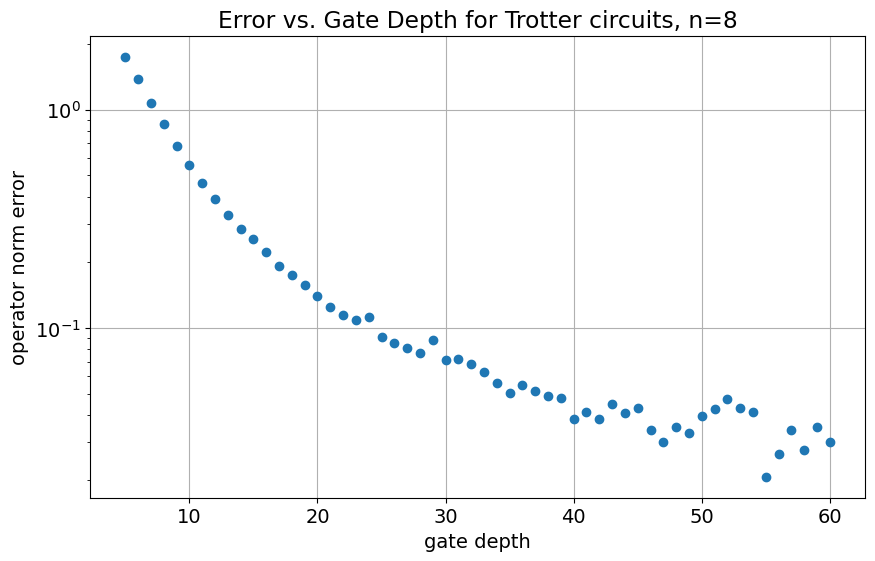

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(trotter_step_counts, error_list, marker='o', linestyle='none')
plt.xlabel('gate depth')
plt.ylabel('operator norm error')
plt.yscale('log') # Added this line for log scale
plt.title(f'Error vs. Gate Depth for Trotter circuits, n={n}')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[4.91483335e-06]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
4.914833352903192e-06.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[4.91483335e-06]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[8.90119385e-06]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 20 instead with accuracy 
7.42052727066029e-06.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/

Schemes contributing points: 8
Total Richardson points plotted: 40


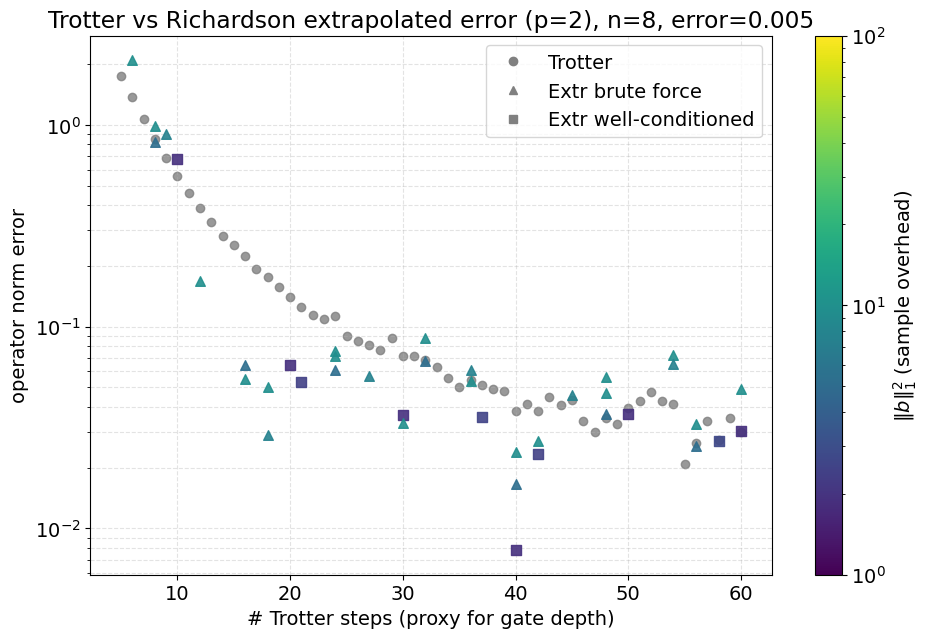

In [ ]:
p_order = 2

# Existing p=2 Trotter operators from earlier cells, keyed by integer step count N.
step_to_trotter = {int(N): op for N, op in zip(trotter_step_counts, err_trotter_operators_list)}
step_min, step_max = min(trotter_step_counts), max(trotter_step_counts)

# Representative schedules from prior data (wc + opt).
active_schemes = [
    {"mode": "wc",  "label": "wc q=[10,4]",      "q_grid": (10, 4),       "b": np.array([1.1904761904761905, -0.19047619047619052]),            "bnorm_sq": 1.907},
    #{"mode": "opt",  "label": "opt q=[3, 6, 7]",      "q_grid": (3, 6, 7),       "b": np.array([0.07499999999999973,-3.6923076923076867,4.617307692307687]), "bnorm_sq": 70.3},
    #{"mode": "opt", "label": "opt q=[1, 3, 4, 5]",   "q_grid": (1, 3, 4, 5),    "b": np.array([-0.00034722222222161037,0.8136160714284095,-4.334391534391033,4.521122685184845]), "bnorm_sq": 93.5},
    #{"mode": "opt", "label": "opt q=[2, 4, 5, 8, 10]", "q_grid": (2, 4, 5, 8, 10), "b": np.array([0.00017636684303445893,-0.15049970605546648,0.706597928820781,-4.149161126940397,4.592886537332048]), "bnorm_sq": 92.15},
    #{"mode": "opt", "label": "opt q=[1, 3, 4, 5, 7, 10]", "q_grid":(1, 3, 4, 5, 7, 10), "b": np.array([-7.306864964126691e-08,0.018105192797205082,-0.400290127254635,1.5698342656318167,-3.6423679322073284,3.454718674101591]),	"bnorm_sq": 82.54},
    {"mode": "wc",  "label": "wc q=[21, 8, 5]",   "q_grid": (21, 8, 5),    "b": np.array([1.240059426647623,-0.2785826021900292,0.0385231755424063]), "bnorm_sq": 2.425},
    {"mode": "wc",  "label": "wc q=[37, 13, 8, 6]",   "q_grid": (37, 13, 8, 6),    "b": np.array([1.229103448754909, -0.288030134860962, 0.06832538379336414, -0.009398697687311205]), "bnorm_sq": 2.544},
    {"mode": "wc",  "label": "wc q=[58, 20, 12, 9, 7]",   "q_grid": (58, 20, 12, 9, 7),    "b": np.array([1.2329216023270066, -0.3013172541768565, 0.08715453229346652, -0.02038862705718869, 0.0016297466135721252]), "bnorm_sq": 2.701},
    #{"mode": "wc",  "label": "wc q=[113, 38, 23, 17, 14, 11, 10]",   "q_grid": (113, 38, 23, 17, 14, 11, 10),    "b": np.array([1.243666681033084,-0.34134077654872713,0.1398809553753111,-0.0570328679198038,0.016204037842288493,-0.0017373227945217385,0.0003592930123689414]), "bnorm_sq": 3.241},
    {"mode": "opt",  "label": "wc q=[5,8]",   "q_grid": (5,8),    "b": np.array([-0.6410256410256407, 1.6410256410256407]), "bnorm_sq": 5.208},
    {"mode": "opt",  "label": "wc q=[2, 4, 6]",   "q_grid": (2, 4, 6),    "b": np.array([0.0416666666666663, -1.0666666666666653, 2.024999999999999]), "bnorm_sq": 9.818},
    {"mode": "opt",  "label": "wc q=[1, 3, 5, 8]",   "q_grid": (1, 3, 5, 8),    "b": np.array([-8.267195767197588e-05,0.10355113636363045,-1.0433360042734787,1.9398675398675203]), "bnorm_sq": 9.529},
    {"mode": "opt",  "label": "wc q=[1, 2, 3, 5, 9]",   "q_grid": (1, 2, 3, 5, 9),    "b": np.array([2.170138888883677e-05,-0.010554524840220167,0.14238281249986873,-0.8650107178284865,1.733160728779949]), "bnorm_sq": 7.569}
    ]

# Keep only valid schemes.
valid_schemes = []
for s in active_schemes:
    if len(s["q_grid"]) != len(s["b"]):
        print(f"Skipping invalid scheme {s['label']}: len(q_grid) != len(b)")
        continue
    valid_schemes.append(s)

# Cache operators so each N is built once.
operator_cache = dict(step_to_trotter)

def get_trotter_operator_for_steps(N):
    N = int(N)
    if N <= 0:
        raise ValueError("Step count N must be positive")
    if N not in operator_cache:
        dt = t / N
        operator_cache[N] = generate_trotter_second_order(n, J, h, t, dt)
    return operator_cache[N]

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(trotter_step_counts, error_list, marker='o', linestyle='none', color='gray', alpha=0.8, label='Trotter (p=2)', zorder=1)

all_bnorm_sq = [s["bnorm_sq"] for s in valid_schemes]
color_norm = LogNorm(vmin=1, vmax=100)

num_points = 0
num_schemes_with_points = 0

for meta in valid_schemes:
    q_grid = tuple(int(q) for q in meta["q_grid"])
    b = np.asarray(meta["b"], dtype=float)
    q_max = max(q_grid)

    # Requirement-driven range: choose integer r = 1/s so that
    # max Trotter step count q_max * r is within [step_min, step_max].
    r_min = int(np.ceil(step_min / q_max))
    r_max = int(np.floor(step_max / q_max))
    if r_min > r_max:
        continue

    x_vals = []
    y_vals = []

    for r in range(r_min, r_max + 1):
        N_values = [int(q * r) for q in q_grid]

        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        for coeff, N_k in zip(b, N_values):
            U_r = U_r + coeff * get_trotter_operator_for_steps(N_k)

        x_vals.append(max(N_values))
        y_vals.append(float(op_norm_error(U_r, exact_operator)))

    if not x_vals:
        continue

    num_schemes_with_points += 1
    num_points += len(x_vals)

    marker = 's' if meta["mode"] == "wc" else '^'
    color = plt.cm.viridis(color_norm(meta["bnorm_sq"]))
    ax.scatter(x_vals, y_vals, color=color, marker=marker, s=48, alpha=0.9, zorder=2)

print(f"Schemes contributing points: {num_schemes_with_points}")
print(f"Total Richardson points plotted: {num_points}")

ax.set_yscale('log')
ax.set_xlabel('# Trotter steps (proxy for gate depth)')
ax.set_ylabel('operator norm error')
ax.set_title(f'Trotter vs Richardson extrapolated error (p={p_order}), n={n}, error={0.005}')
ax.grid(True, which='both', ls='--', alpha=0.35)

handles = [
    plt.Line2D([], [], marker='o', linestyle='none', color='gray', label='Trotter'),
    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Extr brute force'),
    plt.Line2D([], [], marker='s', linestyle='none', color='gray', label='Extr well-conditioned')
]
ax.legend(handles=handles, loc='best')

sm = plt.cm.ScalarMappable(norm=color_norm, cmap=plt.cm.viridis)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\Vert b\Vert_1^2$ (sample overhead)')

plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[2.02397869e-05]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 18 instead with accuracy 
1.4229636970855381e-05.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[1.4229637e-05]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[1.40259036e-05]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 13 instead with accuracy 
5.652594599277968e-06.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen

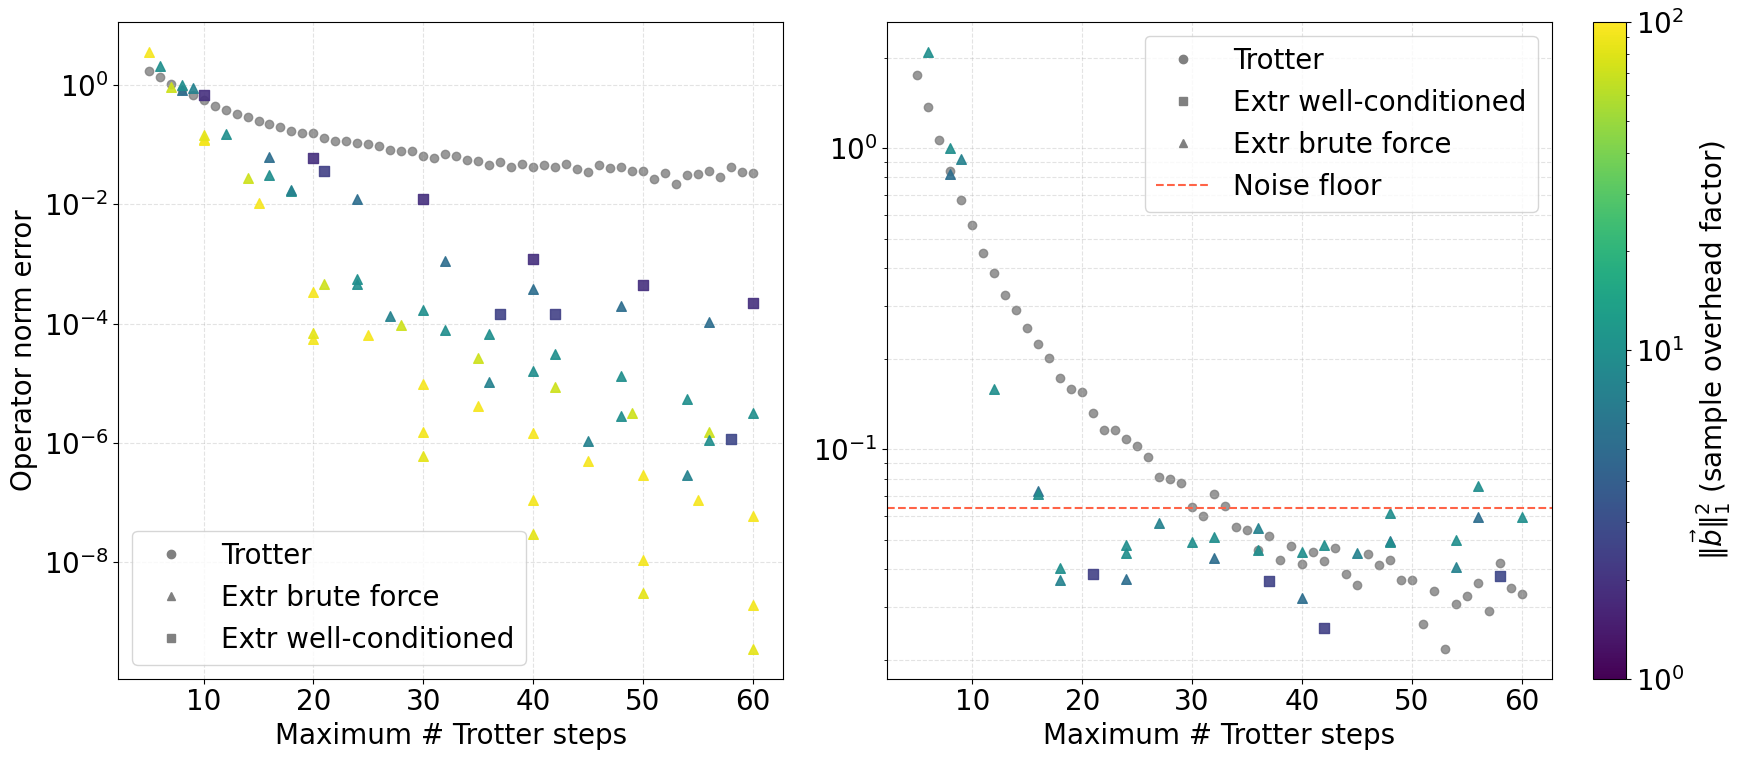

In [ ]:
from matplotlib.colors import LogNorm

# Set global font size for all plots in this figure
plt.rcParams.update({'font.size': 20})

p_order = 2

# Create a figure with two subplots.
# Reduced figsize width further to 14 to make subplots almost square.
# width_ratios [1, 1.25] is kept to ensure visual width equality of the plot boxes.
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1.25]})

# --- First Plot: Trotter vs Richardson extrapolated error ---
ax0 = axes[0]

step_to_trotter_orig = {int(N): op for N, op in zip(trotter_step_counts, trotter_operators_list)}
step_min, step_max = min(trotter_step_counts), max(trotter_step_counts)

active_schemes_orig = [
    {"mode": "wc",  "label": "wc q=[10,4]",      "q_grid": (10, 4),       "b": np.array([1.1904761904761905, -0.19047619047619052]),            "bnorm_sq": 1.907},
    {"mode": "opt",  "label": "opt q=[3, 6, 7]",      "q_grid": (3, 6, 7),       "b": np.array([0.07499999999999973,-3.6923076923076867,4.617307692307687]), "bnorm_sq": 70.3},
    {"mode": "opt", "label": "opt q=[1, 3, 4, 5]",   "q_grid": (1, 3, 4, 5),    "b": np.array([-0.00034722222222161037,0.8136160714284095,-4.334391534391033,4.521122685184845]), "bnorm_sq": 93.5},
    {"mode": "opt", "label": "opt q=[2, 4, 5, 8, 10]", "q_grid": (2, 4, 5, 8, 10), "b": np.array([0.00017636684303445893,-0.15049970605546648,0.706597928820781,-4.149161126940397,4.592886537332048]), "bnorm_sq": 92.15},
    {"mode": "opt", "label": "opt q=[1, 3, 4, 5, 7, 10]", "q_grid":(1, 3, 4, 5, 7, 10), "b": np.array([-7.306864964126691e-08,0.018105192797205082,-0.400290127254635,1.5698342656318167,-3.6423679322073284,3.454718674101591]),	"bnorm_sq": 82.54},
    {"mode": "wc",  "label": "wc q=[21, 8, 5]",   "q_grid": (21, 8, 5),    "b": np.array([1.240059426647623,-0.2785826021900292,0.0385231755424063]), "bnorm_sq": 2.425},
    {"mode": "wc",  "label": "wc q=[37, 13, 8, 6]",   "q_grid": (37, 13, 8, 6),    "b": np.array([1.229103448754909, -0.288030134860962, 0.06832538379336414, -0.009398697687311205]), "bnorm_sq": 2.544},
    {"mode": "wc",  "label": "wc q=[58, 20, 12, 9, 7]",   "q_grid": (58, 20, 12, 9, 7),    "b": np.array([1.2329216023270066, -0.3013172541768565, 0.08715453229346652, -0.02038862705718869, 0.0016297466135721252]), "bnorm_sq": 2.701},
    {"mode": "opt",  "label": "wc q=[5,8]",   "q_grid": (5,8),    "b": np.array([-0.6410256410256407, 1.6410256410256407]), "bnorm_sq": 5.208},
    {"mode": "opt",  "label": "wc q=[2, 4, 6]",   "q_grid": (2, 4, 6),    "b": np.array([0.0416666666666663, -1.0666666666666653, 2.024999999999999]), "bnorm_sq": 9.818},
    {"mode": "opt",  "label": "wc q=[1, 3, 5, 8]",   "q_grid": (1, 3, 5, 8),    "b": np.array([-8.267195767197588e-05,0.10355113636363045,-1.0433360042734787,1.9398675398675203]), "bnorm_sq": 9.529},
    {"mode": "opt",  "label": "wc q=[1, 2, 3, 5, 9]",   "q_grid": (1, 2, 3, 5, 9),    "b": np.array([2.170138888883677e-05,-0.010554524840220167,0.14238281249986873,-0.8650107178284865,1.733160728779949]), "bnorm_sq": 7.569}
]

operator_cache_orig = dict(step_to_trotter_orig)
def get_trotter_operator_for_steps_orig(N):
    N = int(N)
    if N not in operator_cache_orig:
        dt = t / N
        operator_cache_orig[N] = generate_trotter_second_order(n, J, h, t, dt)
    return operator_cache_orig[N]

ax0.plot(trotter_step_counts, error_list, marker='o', linestyle='none', color='gray', alpha=0.8, label='Trotter (p=2)', zorder=1)
color_norm_orig = LogNorm(vmin=1, vmax=100)

for meta in active_schemes_orig:
    q_grid = tuple(int(q) for q in meta["q_grid"])
    b = np.asarray(meta["b"], dtype=float)
    q_max = max(q_grid)
    r_min, r_max = int(np.ceil(step_min / q_max)), int(np.floor(step_max / q_max))
    if r_min > r_max: continue
    x_vals, y_vals = [], []
    for r in range(r_min, r_max + 1):
        N_values = [int(q * r) for q in q_grid]
        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        for coeff, N_k in zip(b, N_values):
            U_r = U_r + coeff * get_trotter_operator_for_steps_orig(N_k)
        x_vals.append(max(N_values))
        y_vals.append(float(op_norm_error(U_r, exact_operator)))
    if not x_vals: continue
    color = plt.cm.viridis(color_norm_orig(meta["bnorm_sq"]))
    ax0.scatter(x_vals, y_vals, color=color, marker='s' if meta["mode"] == "wc" else '^', s=48, alpha=0.9, zorder=2)

ax0.set_yscale('log')
ax0.set_xlabel('Maximum # Trotter steps')
ax0.set_ylabel('Operator norm error')
ax0.grid(True, which='both', ls='--', alpha=0.35)
ax0.legend(handles=[plt.Line2D([], [], marker='o', linestyle='none', color='gray', label='Trotter'),
                    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Extr brute force'),
                    plt.Line2D([], [], marker='s', linestyle='none', color='gray', label='Extr well-conditioned')], loc='best')

# --- Second Plot: simulated measurement noise ---
ax1 = axes[1]
step_to_trotter_err = {int(N): op for N, op in zip(trotter_step_counts, err_trotter_operators_list)}
active_schemes_err = active_schemes_orig[5:] # reuse some wc schemes
operator_cache_err = dict(step_to_trotter_err)
def get_trotter_operator_for_steps_err(N):
    return operator_cache_err[int(N)]

ax1.plot(trotter_step_counts, error_list, marker='o', linestyle='none', color='gray', alpha=0.8, label='Trotter (p=2)', zorder=1)
for meta in active_schemes_err:
    q_grid, b = tuple(int(q) for q in meta["q_grid"]), np.asarray(meta["b"], dtype=float)
    q_max = max(q_grid)
    r_min, r_max = int(np.ceil(step_min / q_max)), int(np.floor(step_max / q_max))
    x_vals, y_vals = [], []
    for r in range(r_min, r_max + 1):
        N_values = [int(q * r) for q in q_grid]
        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        for coeff, N_k in zip(b, N_values):
            try: U_r = U_r + coeff * get_trotter_operator_for_steps_err(N_k)
            except KeyError: U_r = U_r + coeff * add_x_rotations(generate_trotter_second_order(n, J, h, t, t/N_k), n, std_dev=0.008)
        x_vals.append(max(N_values))
        y_vals.append(float(op_norm_error(U_r, exact_operator)))
    if x_vals:
        ax1.scatter(x_vals, y_vals, color=plt.cm.viridis(color_norm_orig(meta["bnorm_sq"])), marker='s' if meta["mode"] == "wc" else '^', s=48, alpha=0.9, zorder=2)

ax1.set_yscale('log')
ax1.set_xlabel('Maximum # Trotter steps')
ax1.grid(True, which='both', ls='--', alpha=0.35)
ax1.axhline(y=0.064, color='tomato', linestyle='--', label='Noise floor')
ax1.legend(handles=[plt.Line2D([], [], marker='o', linestyle='none', color='gray', label='Trotter'),
                    plt.Line2D([], [], marker='s', linestyle='none', color='gray', label='Extr well-conditioned'),
                    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Extr brute force'),
                    plt.Line2D([], [], color='tomato', linestyle='--', label='Noise floor')], loc='best')

sm_err = plt.cm.ScalarMappable(norm=color_norm_orig, cmap=plt.cm.viridis)
sm_err.set_array([])
cbar_err = fig.colorbar(sm_err, ax=ax1)
cbar_err.set_label(r'$\Vert \vec{b}\Vert_1^2$ (sample overhead factor)')

plt.tight_layout()
plt.savefig('combined_trotter_plots.pdf')
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[0.00037027]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
0.0003702712966615582.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[0.00037027]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[4.54904535e-06]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
4.549045353482301e-06.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.p

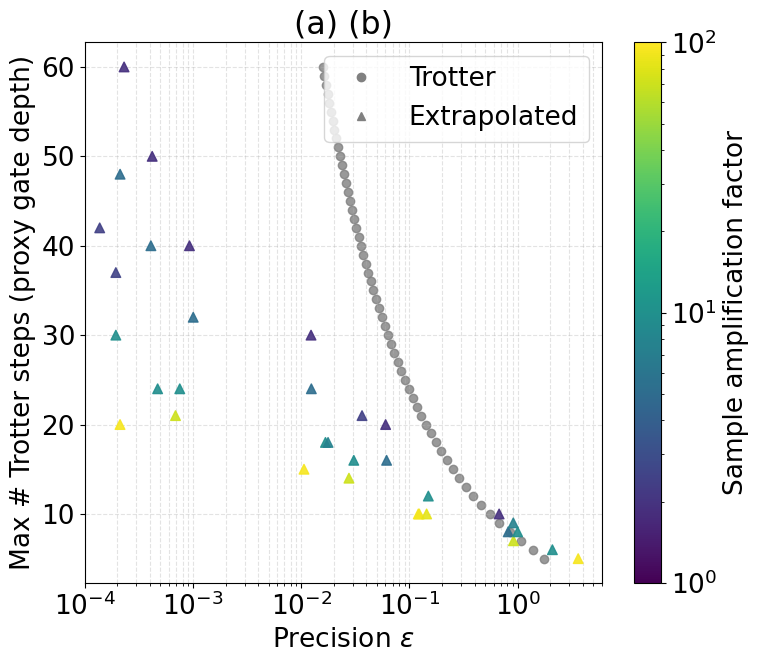

In [ ]:
# summary figure
# Set global font size for all plots in this figure
plt.rcParams.update({'font.size': 19})

p_order = 2

# Create a figure with a single subplot
fig, ax0 = plt.subplots(figsize=(8, 7))

# --- First Plot: Trotter vs Richardson extrapolated error (Error on X-axis) ---

step_to_trotter_orig = {int(N): op for N, op in zip(trotter_step_counts, trotter_operators_list)}
step_min, step_max = min(trotter_step_counts), max(trotter_step_counts)

active_schemes_orig = [
    {"mode": "wc",  "label": "wc q=[10,4]",      "q_grid": (10, 4),       "b": np.array([1.1904761904761905, -0.19047619047619052]),            "bnorm_sq": 1.907},
    {"mode": "opt",  "label": "opt q=[3, 6, 7]",      "q_grid": (3, 6, 7),       "b": np.array([0.07499999999999973,-3.6923076923076867,4.617307692307687]), "bnorm_sq": 70.3},
    {"mode": "opt", "label": "opt q=[1, 3, 4, 5]",   "q_grid": (1, 3, 4, 5),    "b": np.array([-0.00034722222222161037,0.8136160714284095,-4.334391534391033,4.521122685184845]), "bnorm_sq": 93.5},
    {"mode": "opt", "label": "opt q=[2, 4, 5, 8, 10]", "q_grid": (2, 4, 5, 8, 10), "b": np.array([0.00017636684303445893,-0.15049970605546648,0.706597928820781,-4.149161126940397,4.592886537332048]), "bnorm_sq": 92.15},
    {"mode": "opt", "label": "opt q=[1, 3, 4, 5, 7, 10]", "q_grid":(1, 3, 4, 5, 7, 10), "b": np.array([-7.306864964126691e-08,0.018105192797205082,-0.400290127254635,1.5698342656318167,-3.6423679322073284,3.454718674101591]),	"bnorm_sq": 82.54},
    {"mode": "wc",  "label": "wc q=[21, 8, 5]",   "q_grid": (21, 8, 5),    "b": np.array([1.240059426647623,-0.2785826021900292,0.0385231755424063]), "bnorm_sq": 2.425},
    {"mode": "wc",  "label": "wc q=[37, 13, 8, 6]",   "q_grid": (37, 13, 8, 6),    "b": np.array([1.229103448754909, -0.288030134860962, 0.06832538379336414, -0.009398697687311205]), "bnorm_sq": 2.544},
    {"mode": "wc",  "label": "wc q=[58, 20, 12, 9, 7]",   "q_grid": (58, 20, 12, 9, 7),    "b": np.array([1.2329216023270066, -0.3013172541768565, 0.08715453229346652, -0.02038862705718869, 0.0016297466135721252]), "bnorm_sq": 2.701},
    {"mode": "opt",  "label": "wc q=[5,8]",   "q_grid": (5,8),    "b": np.array([-0.6410256410256407, 1.6410256410256407]), "bnorm_sq": 5.208},
    {"mode": "opt",  "label": "wc q=[2, 4, 6]",   "q_grid": (2, 4, 6),    "b": np.array([0.0416666666666663, -1.0666666666666653, 2.024999999999999]), "bnorm_sq": 9.818},
    {"mode": "opt",  "label": "wc q=[1, 3, 5, 8]",   "q_grid": (1, 3, 5, 8),    "b": np.array([-8.267195767197588e-05,0.10355113636363045,-1.0433360042734787,1.9398675398675203]), "bnorm_sq": 9.529},
    {"mode": "opt",  "label": "wc q=[1, 2, 3, 5, 9]",   "q_grid": (1, 2, 3, 5, 9),    "b": np.array([2.170138888883677e-05,-0.010554524840220167,0.14238281249986873,-0.8650107178284865,1.733160728779949]), "bnorm_sq": 7.569}
]

operator_cache_orig = dict(step_to_trotter_orig)
def get_trotter_operator_for_steps_orig(N):
    N = int(N)
    if N not in operator_cache_orig:
        dt = t / N
        operator_cache_orig[N] = generate_trotter_second_order(n, J, h, t, dt)
    return operator_cache_orig[N]

# Calculate error_list for original Trotter operators
error_list_orig = []
for m in trotter_operators_list:
    error = op_norm_error(m, exact_operator)
    error_list_orig.append(error)

# Filter Trotter data points based on the error threshold
plot_trotter_errors = []
plot_trotter_steps = []
for err, steps in zip(error_list_orig, trotter_step_counts):
    if err >= 1.3e-4: # Apply the new filter condition
        plot_trotter_errors.append(err)
        plot_trotter_steps.append(steps)

# Invert axes for ax0 and plot filtered Trotter data
ax0.plot(plot_trotter_errors, plot_trotter_steps, marker='o', linestyle='none', color='gray', alpha=0.8, label='Trotter (p=2)', zorder=1)

color_norm_orig = LogNorm(vmin=1, vmax=100)

# Collect all extrapolated data points first
all_extrapolated_points = [] # List of (error, gate_depth, color)

for meta in active_schemes_orig:
    q_grid = tuple(int(q) for q in meta["q_grid"])
    b = np.asarray(meta["b"], dtype=float)
    q_max = max(q_grid)
    r_min, r_max = int(np.ceil(step_min / q_max)), int(np.floor(step_max / q_max))
    if r_min > r_max: continue

    color = plt.cm.viridis(color_norm_orig(meta["bnorm_sq"])) # Color is per scheme

    for r in range(r_min, r_max + 1):
        N_values = [int(q * r) for q in q_grid]
        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        for coeff, N_k in zip(b, N_values):
            U_r = U_r + coeff * get_trotter_operator_for_steps_orig(N_k)

        # Store (error, gate_depth, color)
        error = float(op_norm_error(U_r, exact_operator))
        gate_depth = max(N_values)
        all_extrapolated_points.append((error, gate_depth, color))

# Sort all extrapolated points by error (x-value)
all_extrapolated_points.sort(key=lambda item: item[0])

# Remove the three points with the smallest errors (as per previous request)
filtered_extrapolated_points = all_extrapolated_points[3:]

# Apply the new filter for x-value (error >= 1.3e-4)
final_plot_extrapolated_points = []
for p in filtered_extrapolated_points:
    if p[0] >= 1.3e-4:
        final_plot_extrapolated_points.append(p)

# Plot the filtered extrapolated points
if final_plot_extrapolated_points:
    final_x_vals = [p[0] for p in final_plot_extrapolated_points]
    final_y_vals = [p[1] for p in final_plot_extrapolated_points]
    final_colors = [p[2] for p in final_plot_extrapolated_points]
    ax0.scatter(final_x_vals, final_y_vals, color=final_colors, marker='^', s=48, alpha=0.9, zorder=2, label='_nolegend_') # label='_nolegend_' to avoid adding multiple entries

ax0.set_xscale('log')  # X-axis (error) is log scale
ax0.set_xlabel(r'Precision $\varepsilon$') # X-axis label
ax0.set_ylabel('Max # Trotter steps (proxy gate depth)') # Y-axis label
ax0.grid(True, which='both', ls='--', alpha=0.35)
ax0.set_xlim(1e-4, ax0.get_xlim()[1]) # Crop x-axis at 10^-4
ax0.legend(handles=[plt.Line2D([], [], marker='o', linestyle='none', color='gray', label='Trotter'),
                    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Extrapolated') # Changed marker to '^'
                    ], loc='upper right')
ax0.set_title('(a) (b)')

sm = plt.cm.ScalarMappable(norm=color_norm_orig, cmap=plt.cm.viridis)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax0)
cbar.set_label('Sample amplification factor')

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig('trotter_error_plot.pdf')

<Figure size 640x480 with 0 Axes>